#**PROYECTO INTELIGENCIA ARTIFICIAL: Detección temprana de cáncer de piel**
####Integrantes:
* Juan Carlos Elizalde Padilla - 2230028
* Juan David Gomez Mosquera - 2230062
* Erick Fabian Rodriguez Marin - 2221914

###**Problema y datos**
El HAM10000 (Human Against Machine with 10000 training images) es un dataset multimodal de dermatología que combina imágenes médicas reales con datos clínicos tabulares. Contiene 10,015 imágenes dermatoscópicas de lesiones de piel clasificadas en 7 tipos de cáncer y condiciones dermatológicas, recolectadas de hospitales en Austria y Australia durante más de 20 años. Es un dataset de referencia académica mundial, publicado en la revista Scientific Data de Nature.
TIPO DE FORMATO: Imágenes JPG + múltiples archivos CSV NÚMERO DE REGISTROS: 10,015 imágenes / filas en metadata NÚMERO DE VARIABLES: 7 columnas clínicas en metadata + versiones tabulares de imágenes en píxeles. TARGET: dx - tipo de lesión (Benigna - Maliciosa.) TIPOS DE VARIABLES: Numéricas (edad), categóricas (sexo, localización corporal, tipo de diagnóstico, tipo de lesión) e imagen convertida a píxeles en CSV.

El desafío es clasificar correctamente el tipo de diagnóstico según si es benigno o maligno por medio de imágenes.

Dasaset recuperado de: [Kaggle](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000?select=HAM10000_metadata.csv)


###**Justificación de la IA**
Dada la gran variabilidad visual y el desequilibrio de datos en la clasificación de lesiones cutáneas, un modelo de Inteligencia Artificial supervisada puede identificar complejos patrones en imágenes médicas con mayor exactitud, lo que puede ayudar en la diferenciación entre lesiones cutáneas benignas y malignas [(Esteva et al., 2017)](https://www.nature.com/articles/nature21056). En cuanto a su aplicación, dado que se conoce que la detección temprana de cáncer de piel mejora decisiones clínica y aumenta las posibilidades de un tratamiento exitoso, se puede concluir que el modelo es apropiado para el problema [(Skin Cancer Classification With Deep Learning: A Systematic Review)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9327733/).

---
#**1. Conjunto de datos**
---

Importación de librerías:

In [ ]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import seaborn as sns
from io import StringIO

Carga dataset:

In [ ]:
def cargar_csv(file_id):
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    return pd.read_csv(StringIO(requests.get(url).text))

meta     = cargar_csv("1HAcuf87ADCTFmT048xkx9LImkwnPjWwR")
ham8_l   = cargar_csv("1STRxSq4TZfNoS3SWKVtHzn4swVRx2wCU")
ham8_rgb = cargar_csv("1xfd7LOevJ-ueN4EufCK9tezH5tOq_sGI")
ham28_l  = cargar_csv("1BaP97p2QPDSgqwtB-FAXazXHjzGQ6yLv")
ham28_rgb= cargar_csv("1c9OPTuKl8k3xAVHMSfQV5-SvsoGGXoT6")

for nombre, df in [("meta", meta), ("ham8_l", ham8_l), ("ham8_rgb", ham8_rgb), ("ham28_l", ham28_l), ("ham28_rgb", ham28_rgb)]:
    print(f"{nombre}: {df.shape}")


meta: (10015, 7)
ham8_l: (10015, 65)
ham8_rgb: (10015, 193)
ham28_l: (10015, 785)
ham28_rgb: (10015, 2353)


Creación de la variable objetivo

In [ ]:
# El target es identificar mediante una fotografia si la lesion es benigna o maligna,
# para ello necesitamos crear una columna de target en el dataset de meta donde se
# especifique si lo es o no.
malignos = ['mel', 'bcc', 'akiec']
meta['target'] = meta['dx'].isin(malignos).astype(int)

Visualización de la metadata

In [ ]:
meta

,lesion_id,image_id,dx,dx_type,age,sex,localization,target
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,0
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,0
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,0
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,0
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,0
...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,1
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,1
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,1
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,1


---
#**2. Análisis exploratorio de datos**
---

### 2.1 Variable objetivo: target - Benigno o no benigno.
La variable target es una variable creada a partir de la variable dx, la cuál describe si una imagen es de una lesión benigna o maligna. Dicha clasificación fué posible gracias al [artículo asociado al dataset](https://www.nature.com/articles/sdata2018161).

La clasificación para cada una de las categorías son:

**Malignas (1)**

*   akiec: Se considera maligna al ser un tipo de lesión precursora la cuál puede avanzar hasta volverse un cáncer maligno.
*  bcc: Es maligna porque se define directamente como “cáncer de piel” y puede crecer y dañar el tejido si no se trata.
* mel: Es maligna porque es un tipo de cáncer de piel que puede crecer, invadir tejidos y extenderse a otras partes del cuerpo.

**Benignas (0)**

* bkl: Es benigna porque agrupa lesiones no cancerosas que no invaden ni se propagan.

* df: Es benigna porque es una lesión no cancerosa, generalmente causada por una reacción de la piel y sin crecimiento agresivo.

* nv: Es benigna porque corresponde a lunares comunes, que son crecimientos de células pero no cancerosos.

* vasc: Es benigna porque son lesiones de vasos sanguíneos (como angiomas) que no son cáncer ni se expanden de forma peligrosa.

Cálculo de las estadísticas y representación gráfica de la variable dx:

In [ ]:
frecuencia_target = meta['target'].value_counts()
porcentaje_target = meta['target'].value_counts(normalize=True) * 100

resumen_target = pd.DataFrame({
    'Conteo': frecuencia_target,
    'Porcentaje (%)': porcentaje_target.round(2)
})

print("Estadísticas de la variable target:")
print(resumen_target)

Estadísticas de la variable target:
        Conteo  Porcentaje (%)
target                        
0         8061           80.49
1         1954           19.51


Para esta variable podemos ver cómo la mayoría de casos son benignos (0) con una cantidad total de 8061 (80.49%), siendo el resto de casos malignos con un total de 1954 (19.51%). Gracias a esto, se puede ver que hay un desbalance bastante amplio en los datos lo cual puede sesgar al modelo hacia los casos benignos, por lo que será necesario considerar este desbalance durante el entrenamiento y la evaluación. Este comportamiento se puede ver más fácil gracias al siguiente diagrama de barras:

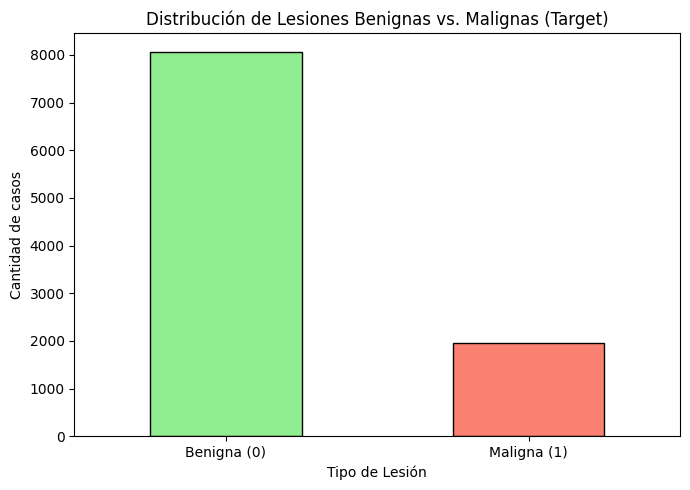

In [ ]:
plt.figure(figsize=(7, 5))
frecuencia_target.plot(kind='bar', color=['lightgreen', 'salmon'], edgecolor='black')
plt.title('Distribución de Lesiones Benignas vs. Malignas (Target)')
plt.xlabel('Tipo de Lesión')
plt.ylabel('Cantidad de casos')
plt.xticks(ticks=[0, 1], labels=['Benigna (0)', 'Maligna (1)'], rotation=0)
plt.tight_layout()
plt.show()

### 2.2 Variable: dx - Tipo de lesión.
La variable dx describe el diagnóstico clínico de la lesión cutánea que aparece en la imagen.

Esta variable categórica contiene las siguientes categorías:

*   akiec: Actinic keratoses / intraepithelial carcinoma (enfermedad de Bowen).
Es una Lesión precancerosa o carcinoma temprano.
*   bcc: Basal cell carcinoma (Cáncer de piel).
*   bkl: Benign keratosis-like lesions (Lesiones benignas).
*   df: Dermatofibroma (Una lesión benigna).
*   mel: Melanoma (Cáncer de piel maligno).
*   nv: Melanocytic nevus (Lunar benigno).
*   vasc: Vascular lesions (Lesiones vasculares).

Cálculo de las estadísticas y representación gráfica de la variable dx:

In [ ]:
frecuencia_dx = meta['dx'].value_counts()
porcentaje_dx = meta['dx'].value_counts(normalize=True) * 100

resumen_dx = pd.DataFrame({
    'Conteo': frecuencia_dx,
    'Porcentaje (%)': porcentaje_dx.round(2)
})

print("Estadísticas:")
print(resumen_dx)

Estadísticas:
       Conteo  Porcentaje (%)
dx                           
nv       6705           66.95
mel      1113           11.11
bkl      1099           10.97
bcc       514            5.13
akiec     327            3.27
vasc      142            1.42
df        115            1.15


Para esta variable podemos ver cómo la mayoría de casos son lunares benignos (nv) con una cantidad total de 6705 (66.95%), seguidos de melanomas y lesiones tipo queratosis benigna (bkl), con cantidades totales de 1113 (11.11%) y 1099 (10.97%) respectivamente.

Este comportamiento se puede observar de manera gráfica con por medio del siguente diagrama de barras:

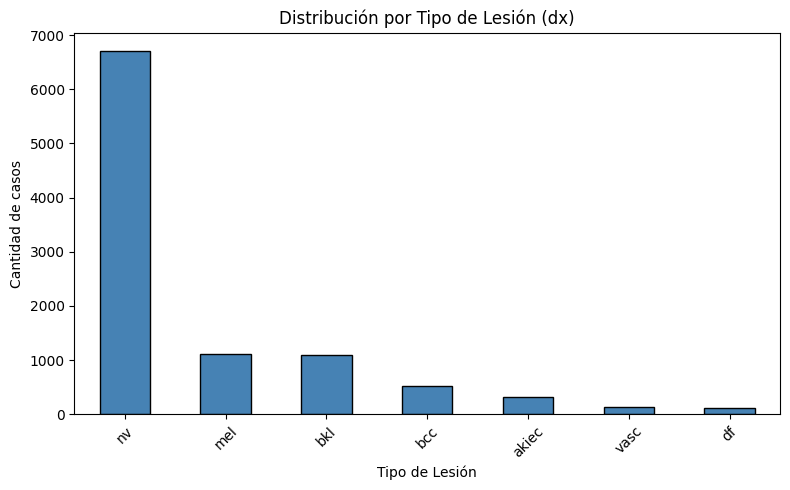

In [ ]:
plt.figure(figsize=(8, 5))
frecuencia_dx.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribución por Tipo de Lesión (dx)')
plt.xlabel('Tipo de Lesión')
plt.ylabel('Cantidad de casos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.3 Variable: location - Localización de lesión.
La variable location describe la localización anatómica del cuerpo donde se encuentra la lesión cutánea mostrada en la imagen.

Esta variable categórica contiene las siguientes categorías:

* abdomen: Lesión ubicada en la zona del abdomen.

* acral: Lesión localizada en zonas acrales del cuerpo, principalmente palmas de las manos, plantas de los pies o dedos.

* back: Lesión ubicada en la espalda.

* chest: Lesión localizada en el pecho o tórax.

* ear: Lesión ubicada en la oreja.

* face: Lesión localizada en la cara.

* foot: Lesión ubicada en el pie.

* hand: Lesión localizada en la mano.

* lower extremity: Lesión ubicada en las extremidades inferiores (principalmente piernas).

* neck: Lesión localizada en el cuello.

* scalp: Lesión ubicada en el cuero cabelludo.

* trunk: Lesión localizada en el tronco del cuerpo (zona central del torso).

* upper extremity: Lesión ubicada en las extremidades superiores (principalmente brazos).

* unknown: La localización anatómica de la lesión no está especificada o es desconocida.

Cálculo de las estadísticas y representación gráfica de la variable location:

In [ ]:
frecuencia_location = meta['localization'].value_counts()
porcentaje_location = meta['localization'].value_counts(normalize=True) * 100

resumen_location = pd.DataFrame({
    'Conteo': frecuencia_location,
    'Porcentaje (%)': porcentaje_location.round(2)
})

print("Estadísticas de la variable localización:")
print(resumen_location)

Estadísticas de la variable localización:
                 Conteo  Porcentaje (%)
localization                           
back               2192           21.89
lower extremity    2077           20.74
trunk              1404           14.02
upper extremity    1118           11.16
abdomen            1022           10.20
face                745            7.44
chest               407            4.06
foot                319            3.19
unknown             234            2.34
neck                168            1.68
scalp               128            1.28
hand                 90            0.90
ear                  56            0.56
genital              48            0.48
acral                 7            0.07


Para esta variable podemos ver cómo la mayoría de los lugares en donde ocurren los diagnósticos es en la espalda con una cantidad total de 2192 casos (21.89%), seguido de las extremidades inferiores y del torso, con cantidades totales de casos presentados de 2077 (20.74%) y 1404 (14.02%) respectivamente.


Dicho comportamiento se puede apreciar más por medio del siguiente gráfico de pastel:

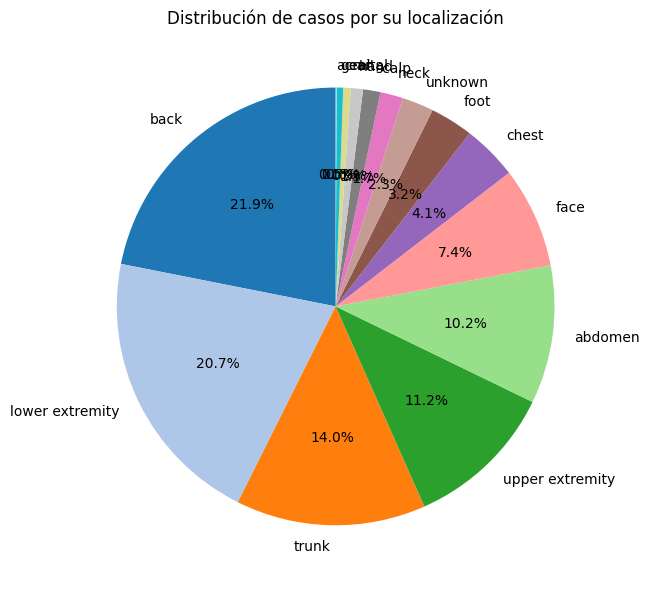

In [ ]:
plt.figure(figsize=(8, 6))
frecuencia_location.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='tab20')
plt.title('Distribución de casos por su localización')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 2.4 Variable: dx_type - Método clinico del diagnóstico.
La variable dx_type indica el método clínico con el que fue confirmado
el diagnóstico de cada lesión de piel. Es una variable categórica con
4 posibles valores: histo (histopatología), follow_up (seguimiento clínico),
consensus (consenso de expertos) y confocal (microscopía confocal).

Es importante entender cómo fue diagnosticada cada lesión porque no todos los métodos tienen el mismo nivel de certeza clínica, por ejemplo una biopsia histopatológica es el estándar en dermatología, mientras que el
consenso de expertos tiene un margen de error mayor.

dx_type
           Conteo  Porcentaje (%)
dx_type                          
histo        5340           53.32
follow_up    3704           36.98
consensus     902            9.01
confocal       69            0.69


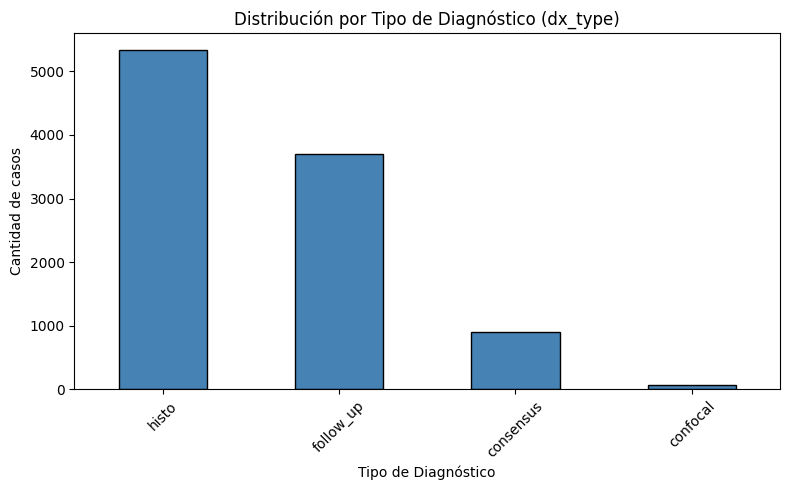

In [ ]:
frecuencia = meta['dx_type'].value_counts()
porcentaje = meta['dx_type'].value_counts(normalize=True) * 100

resumen = pd.DataFrame({
    'Conteo': frecuencia,
    'Porcentaje (%)': porcentaje.round(2)
})
print("dx_type")
print(resumen)
plt.figure(figsize=(8, 5))
frecuencia.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribución por Tipo de Diagnóstico (dx_type)')
plt.xlabel('Tipo de Diagnóstico')
plt.ylabel('Cantidad de casos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En esta grafica podemos observar que el tipo de diagnóstico más frecuente es histopatología (histo) con 5,340 casos (53.32%), seguido de seguimiento clínico (follow_up) con 3,704 casos (36.98%), consenso de expertos con 902 casos (9.01%) y microscopía confocal con apenas 69 casos (0.69%). Es importante para mencionar que más del 53% de los diagnósticos fueron confirmados por biopsia histopatológica significa que el dataset tiene un poco mas de la mitad con confirmacion clinica, es decir no son diagnósticos a ojo, son confirmados por laboratorio.

/tmp/ipykernel_286/2586582090.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=meta, x='dx_type', y='age',


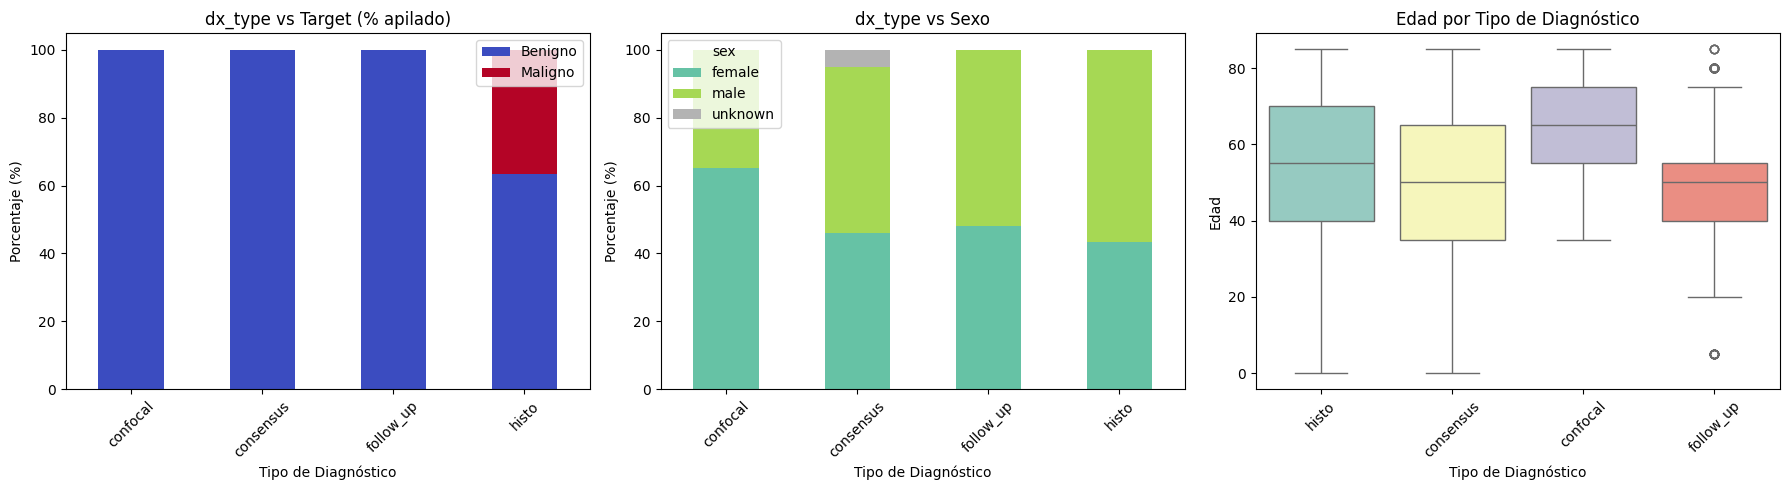

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# dx_type vs target — ¿qué método diagnóstico detecta más malignos?
cross1 = pd.crosstab(meta['dx_type'], meta['target'], normalize='index') * 100
cross1.plot(kind='bar', stacked=True, colormap='coolwarm', ax=axes[0])
axes[0].set_title('dx_type vs Target (% apilado)')
axes[0].set_xlabel('Tipo de Diagnóstico')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['Benigno', 'Maligno'])

# dx_type vs sex — ¿hay diferencia por género?
cross2 = pd.crosstab(meta['dx_type'], meta['sex'], normalize='index') * 100
cross2.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[1])
axes[1].set_title('dx_type vs Sexo')
axes[1].set_xlabel('Tipo de Diagnóstico')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=45)

# dx_type vs age — ¿a qué edad se usa cada método diagnóstico?
sns.boxplot(data=meta, x='dx_type', y='age',
            palette='Set3', ax=axes[2])
axes[2].set_title('Edad por Tipo de Diagnóstico')
axes[2].set_xlabel('Tipo de Diagnóstico')
axes[2].set_ylabel('Edad')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

OBSERVACIONES: dx_type vs otras variables

Al cruzar dx_type con el target se observa que únicamente las lesiones
diagnosticadas por histopatología (histo) contienen casos malignos,
mientras confocal, consensus y follow_up son 100% benignos. Esto
refleja que la biopsia es el estándar de oro para confirmar malignidad.

Al cruzar con sexo se observa que histo tiene mayoría masculina,
sugiriendo que los hombres llegan con mayor frecuencia a procedimientos
invasivos de confirmación.

Al cruzar con edad se observa que follow_up agrupa los pacientes más
jóvenes mientras confocal los más mayores, lo que indica que el método
diagnóstico también está relacionado con la edad del paciente

### 2.5 Variable: age - Edad del paciente.
La variable age representa la edad en años del paciente al momento
del diagnóstico. Es una variable numérica que va desde los
0 hasta los 85 años. Analizar la distribución de edad es relevante
porque el cáncer de piel tiene una relación directa con la edad debido a factores principales como la exposición acumulada al sol a lo largo de los años aumenta el riesgo de desarrollar lesiones malignas.

Edad
Media: 51.86
Desviación estándar: 16.97
Mediana: 50.0
IQR: 25.0
Mínimo: 0.0
Máximo: 85.0
Valores nulos: 57


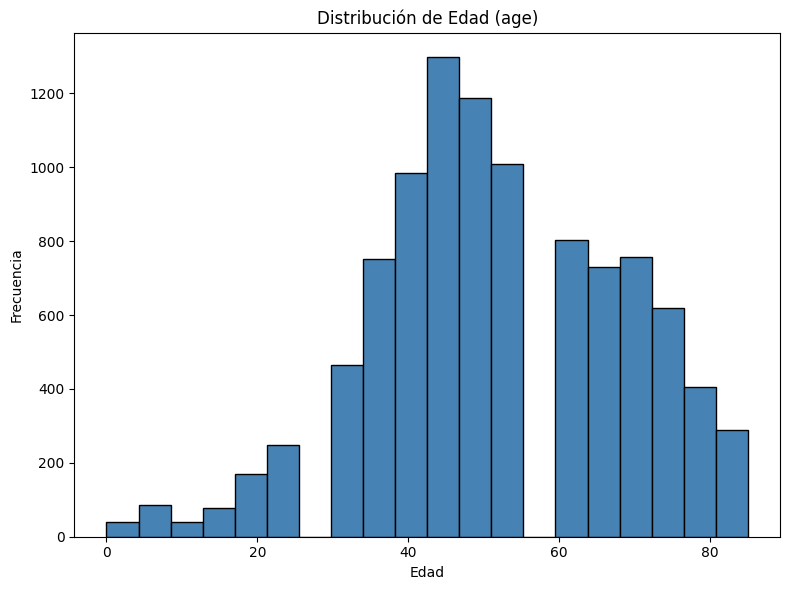

In [ ]:
# AGE
# Estadísticas básicas
print("Edad")
print("Media:", round(meta['age'].mean(), 2))
print("Desviación estándar:", round(meta['age'].std(), 2))
print("Mediana:", meta['age'].median())
print("IQR:", meta['age'].quantile(0.75) - meta['age'].quantile(0.25))
print("Mínimo:", meta['age'].min())
print("Máximo:", meta['age'].max())
print("Valores nulos:", meta['age'].isnull().sum())

# Histograma
plt.figure(figsize=(8, 6))
plt.hist(meta['age'].dropna(), bins=20, color='steelblue', edgecolor='black')
plt.title('Distribución de Edad (age)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

La distribución de age es asimétrica con. El histograma muestra dos concentraciones principales:una alrededor de los 40 años y otra alrededor de los 65 años,con muy pocos pacientes menores de 20 años. Esto es consistente
con la literatura clínica leida debiado a que el cáncer de piel es más frecuente
en adultos mayores de 40 años. Dado que el histograma es asimétrico, las estadísticas tienen como mediana de 50 años y un rango intercuartil de 25 años (Q1=40, Q3=65).

El boxplot revela un outlier en edad 0, que representa claramente
un error de registro en los datos y no un paciente real recién nacido.
Adicionalmente se encontraron 57 valores nulos y un valor atípico de 0 años que representa un error de registro.

In [ ]:
# VER LOS NULOS
print("Valores nulos en age:", meta['age'].isnull().sum())
print("Porcentaje nulo:", (meta['age'].isnull().sum() / len(meta) * 100).round(2), "%")

# Ver las filas donde age es nulo
print(meta[meta['age'].isnull()][['lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization']])

Valores nulos en age: 57
Porcentaje nulo: 0.57 %
        lesion_id   dx    dx_type  age      sex     localization
968   HAM_0001186  bkl  consensus  NaN  unknown          unknown
969   HAM_0002660  bkl  consensus  NaN  unknown          unknown
970   HAM_0000372  bkl  consensus  NaN  unknown          unknown
971   HAM_0000948  bkl  consensus  NaN  unknown          unknown
972   HAM_0000983  bkl  consensus  NaN  unknown          unknown
973   HAM_0007281  bkl  consensus  NaN  unknown          unknown
974   HAM_0001561  bkl  consensus  NaN  unknown          unknown
975   HAM_0000825  bkl  consensus  NaN  unknown          unknown
977   HAM_0006074  bkl  consensus  NaN  unknown          unknown
978   HAM_0006074  bkl  consensus  NaN  unknown          unknown
1886  HAM_0000169  mel      histo  NaN     male             face
1887  HAM_0000169  mel      histo  NaN     male             face
7558  HAM_0007278   nv      histo  NaN   female            chest
7961  HAM_0002417   nv      histo  NaN   

In [ ]:
# Ver cuántas filas tienen age nulo
print("Filas con age nulo antes:", meta['age'].isnull().sum())

# Eliminar filas donde age es nulo
meta = meta.dropna(subset=['age'])

Filas con age nulo antes: 57


Se decide eliminar los valores de edad debido a que solo representan el 0.57 porciento de los datos totales y de igual manera en otras columnas tambien se observan valores atipicos, de tal manera no vale la pena intentar arreglar o acomodar estos tipos de valores nulos.


/tmp/ipykernel_286/321702373.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=meta, x='target', y='age',


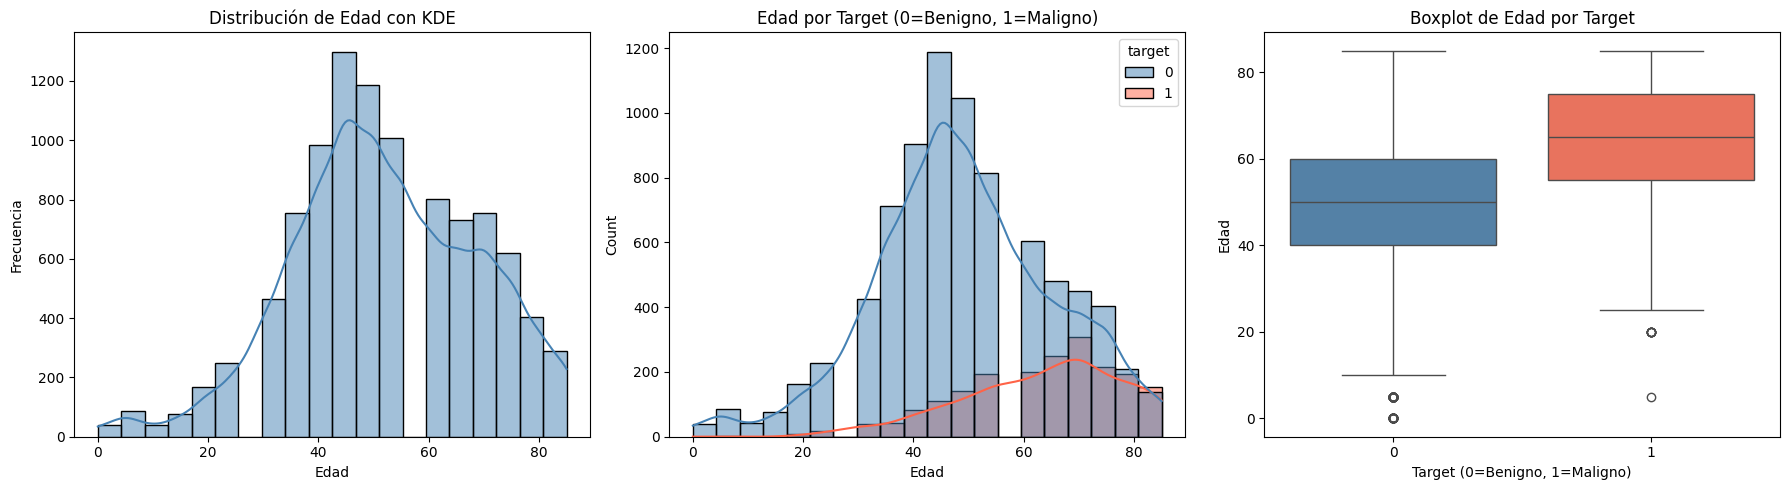

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma con KDE encima, muestra mejor los dos picos
import seaborn as sns
sns.histplot(meta['age'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribución de Edad con KDE')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Separado por target, ve si los dos picos vienen de benignos vs malignos
sns.histplot(data=meta, x='age', hue='target', bins=20, kde=True,
             palette={0:'steelblue', 1:'tomato'}, ax=axes[1])
axes[1].set_title('Edad por Target (0=Benigno, 1=Maligno)')
axes[1].set_xlabel('Edad')

# Boxplot separado por target, compara rangos de edad entre grupos
sns.boxplot(data=meta, x='target', y='age',
            palette={'0':'steelblue', '1':'tomato'}, ax=axes[2]) # Fixed: changed palette keys to strings
axes[2].set_title('Boxplot de Edad por Target')
axes[2].set_xlabel('Target (0=Benigno, 1=Maligno)')
axes[2].set_ylabel('Edad')

plt.tight_layout()
plt.show()

OBSERVACIONES: age vs target

La distribución bimodal de age se explica al separar por target.
Los casos benignos se concentran alrededor de los 45 años mientras
los malignos se concentran entre los 60 y 70 años, con una diferencia
de aproximadamente 15 años entre las medianas de ambos grupos.
Esto indica que la edad es una variable con poder discriminativo
real para el modelo — los pacientes mayores tienen mayor probabilidad
de presentar lesiones malignas, lo cual es consistente con la
literatura clínica sobre daño solar acumulado.

### 2.6 Variable: sex - Sexo biológico del paciente.
La variable sex representa el sexo biológico del paciente al momento del diagnóstico. Es una vairable categórica que contiene las siguientes categorías:
*   male: Paciente de sexo masculino.
*   female: Paciente de sexo femenino.
*   unknown: Sexo no registrado.





Cálculo de las estadisticas y representación gráfica de la variable sex:

In [ ]:
frecuencia_sex = meta['sex'].value_counts()
porcentaje_sex = meta['sex'].value_counts(normalize=True) * 100

resumen_sex = pd.DataFrame({
    'Conteo': frecuencia_sex,
    'Porcentaje (%)': porcentaje_sex.round(2)
})

print("Estadísticas:")
print(resumen_sex)

Estadísticas:
         Conteo  Porcentaje (%)
sex                            
male       5400           54.23
female     4548           45.67
unknown      10            0.10


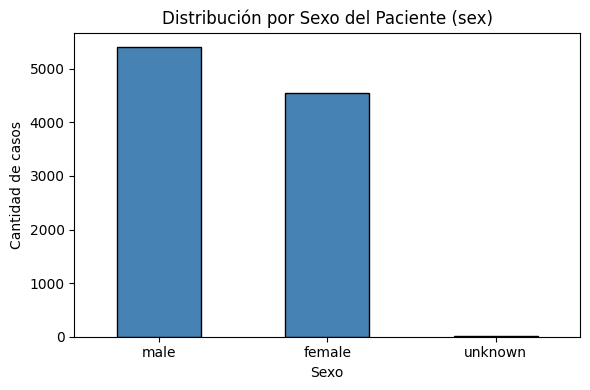

In [ ]:
plt.figure(figsize=(6, 4))
frecuencia_sex.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribución por Sexo del Paciente (sex)')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de casos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Para esta variable podemos ver cómo la mayoría de los casos corresponden a pacientes de sexo masculino, seguidos de pacientes de sexo femenino, con una menor proporción de casos con sexo desconocido. Es importante tener en cuenta este desequilibrio entre sexos en el análisis, ya que, de acuerdo a la evidencia científica, existen algunas lesiones cutáneas, como el melanoma, que pueden presentar diferencias según el sexo del paciente. Observamos una cantidad pequeña de datos con un valor unknown (0.57%), estas indican imagenes en las que esta informacion no estuvo disponible, por lo que se tomo la desicion de eliminar dichas muestras para la etapa de entrenamiento del modelo con el fin de mantener la calidad de la información suministrada al modelo sin sacrificar si capacidad de aprendizaje [Medium](https://medium.com/@nahmed3536/exploring-the-ham10000-dataset-355a9c79116b).

---
#**3.  Tratamiento de Datos y Patrones**
---

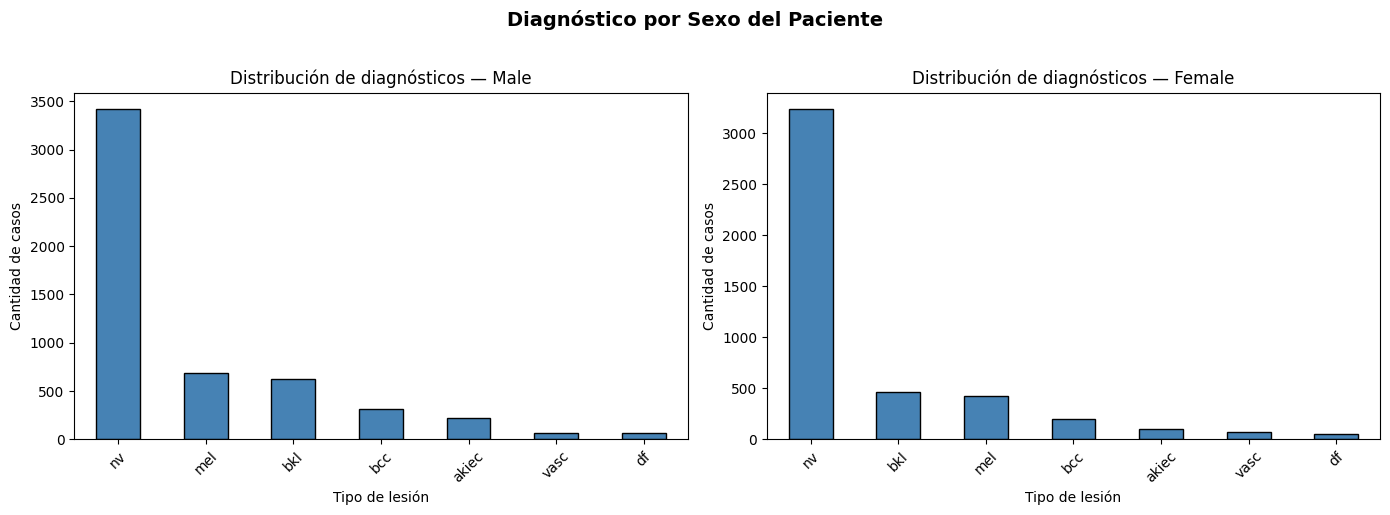

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sexo in zip(axes, ['male', 'female']):
    datos = meta[meta['sex'] == sexo]['dx'].value_counts()
    datos.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Distribución de diagnósticos — {sexo.capitalize()}')
    ax.set_xlabel('Tipo de lesión')
    ax.set_ylabel('Cantidad de casos')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Diagnóstico por Sexo del Paciente', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

En ambos grupos el lunar benigno (nv) es el diagnóstico más frecuente, sin embargo, en pacientes masculinos se observa una mayor presencia relativa de lesiones malignas como el melanoma (mel) y el carcinoma basocelular (bcc).

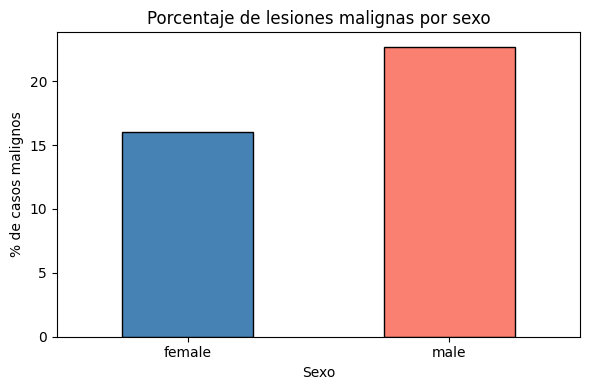

In [ ]:
malignidad_sexo = meta[meta['sex'].isin(['male', 'female'])].groupby('sex')['target'].mean() * 100

plt.figure(figsize=(6, 4))
malignidad_sexo.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Porcentaje de lesiones malignas por sexo')
plt.xlabel('Sexo')
plt.ylabel('% de casos malignos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

A partir de esto, se observa una diferencia aproximada de  puntos porcentuales en la proporción de lesiones malignas entre géneros, siendo mayor en hombres. Esta diferencia puede estar influenciada por la distribución de los datos en el dataset, como la cantidad de imágenes por sexo, por lo que debe interpretarse teniendo en cuenta este posible sesgo.

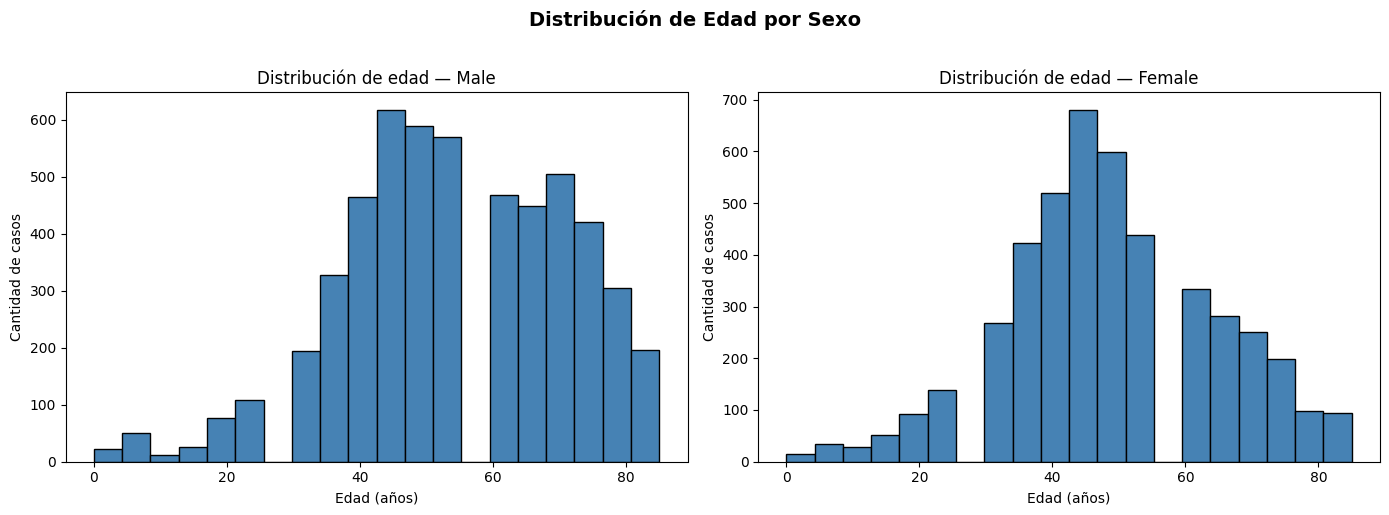

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sexo in zip(axes, ['male', 'female']):
    datos = meta[meta['sex'] == sexo]['age'].dropna()
    datos.plot(kind='hist', bins=20, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Distribución de edad — {sexo.capitalize()}')
    ax.set_xlabel('Edad (años)')
    ax.set_ylabel('Cantidad de casos')

plt.suptitle('Distribución de Edad por Sexo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Ambos grupos presentan una distribución similar, con una concentración principal en el rango de 40 a 55 años y una segunda acumulación entre los 60 y 75 años. Esto sugiere  que la edad promedio de los pacientes es comparable entre hombres y mujeres, por lo que las diferencias observadas anteriormente con respecto a la tasa de malignidad no pueden ser explicadas únicamente por diferencias con respecto a la edad, sugiriendo asi que el sexo puede ser un factor de riesgo independiente.

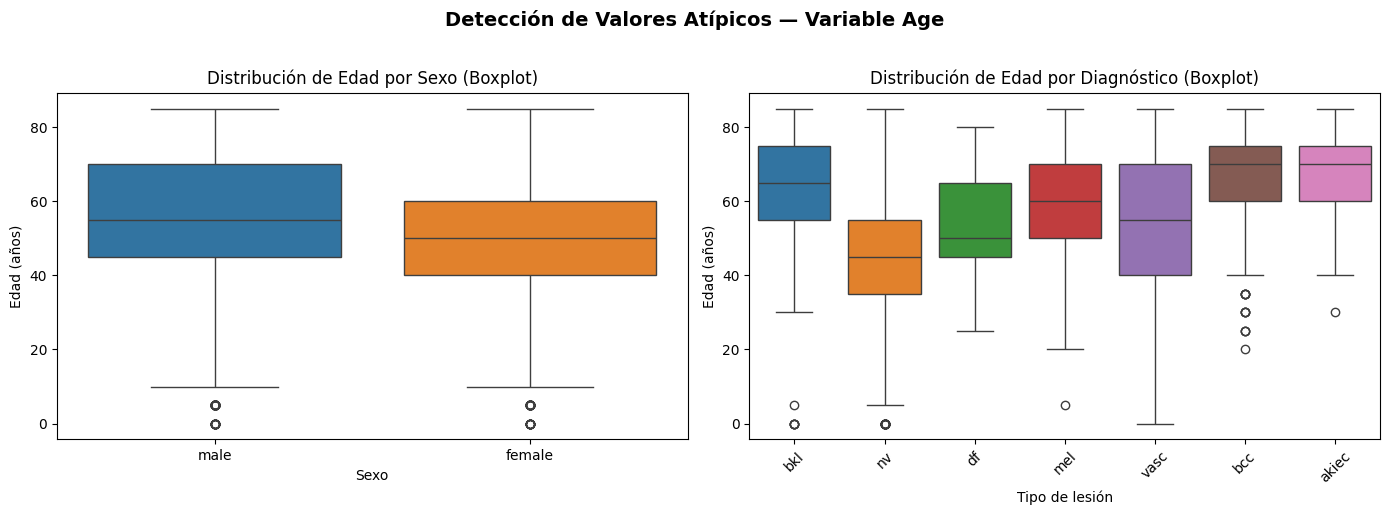

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de edad por sexo
sns.boxplot(data=meta[meta['sex'].isin(['male', 'female'])],
            x='sex', y='age', hue='sex', legend=False, ax=axes[0])
axes[0].set_title('Distribución de Edad por Sexo (Boxplot)')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Edad (años)')

# Boxplot de edad por diagnóstico
sns.boxplot(data=meta, x='dx', y='age', hue='dx', legend=False, ax=axes[1])
axes[1].set_title('Distribución de Edad por Diagnóstico (Boxplot)')
axes[1].set_xlabel('Tipo de lesión')
axes[1].set_ylabel('Edad (años)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Detección de Valores Atípicos — Variable Age', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Se pueden identificar los valores atípicos en la variable age se tratan de pacientes con edades cercanas a 0 años y que pueden ser tanto del sexo masculino como del sexo femenino, y en diaganosticos como bkl, nv y mel. Es importante aclarar que los valores en blanco que se encuentran en los histogramas de distribucion de la edad no se deben a la existencia de valores nulos ni a errores en los datos, sino que simplemente se deben a los rangos de edad en los que no se registraron pacientes en el dataset.

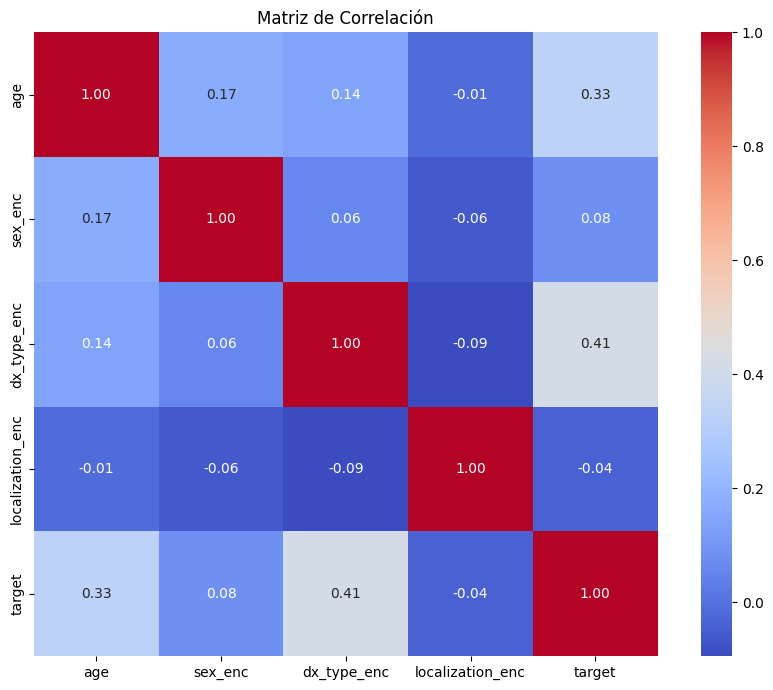

In [ ]:
# Matriz de correlacion respecto a la variable objetivo
meta_corr = meta[['age', 'sex', 'dx_type', 'localization', 'target']].copy()

meta_corr['sex_enc'] = meta_corr['sex'].fillna('unknown').astype('category').cat.codes
meta_corr['dx_type_enc'] = meta_corr['dx_type'].astype('category').cat.codes
meta_corr['localization_enc'] = meta_corr['localization'].astype('category').cat.codes

corr_matrix = meta_corr[['age', 'sex_enc', 'dx_type_enc', 'localization_enc', 'target']].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

La matriz de correlación muestra cómo las variables se relacionan con el target. La variable que demuestra la menor correlación es la localización de la lesión, por lo que se puede inferir que en este dataset el tipo de lesión (benigna o maligna) no depende fuertemente de la zona del cuerpo donde se encuentra. De igual forma, el género presenta una correlación muy baja, por lo que no parece ser una variable determinante para este problema.

Por otro lado, las variables que muestran mayor relación con el target son el tipo de diagnóstico y la edad del paciente, aunque sus valores siguen siendo moderados. Esto indica que, si bien aportan información relevante, ninguna variable por sí sola explica completamente el comportamiento del target, por lo que será necesario considerar la combinación de varias variables para el modelado.

---
#**4.  Conclusiones**
---

A partir del análisis exploratorio, se puede concluir que el dataset presenta un desbalance en la variable objetivo, con una mayor proporción de lesiones benignas en comparación con las malignas, lo cual puede influir en el comportamiento de los modelos de clasificación. Además, se observa una alta variabilidad en los tipos de lesiones, siendo los nevus (nv) los más frecuentes, lo que indica una distribución no uniforme entre las clases.

En cuanto a las variables analizadas, la edad y el tipo de diagnóstico muestran cierta relación con el target, lo que sugiere que pueden aportar información relevante para el modelo. Por otro lado, variables como el sexo y la localización presentan una menor relación individual, por lo que su impacto podría ser limitado si se consideran de forma aislada. También se identificaron algunos problemas de calidad de datos, como valores nulos y registros atípicos en la variable edad, los cuales deben tenerse en cuenta durante el análisis.

Para los próximos pasos, se plantea el desarrollo de un modelo de clasificación que permita predecir si una lesión es benigna o maligna a partir de las imágenes disponibles, considerando el desbalance de clases y evaluando su desempeño mediante métricas adecuadas para este tipo de problema. Esto permitirá establecer una base para mejorar progresivamente la capacidad predictiva del modelo.